In [20]:
import torch
from torch.utils.data import Dataset
import torchvision
import random
import matplotlib.pyplot as plt
import numpy as np
import torchvision.transforms as transforms
from torchvision.transforms import InterpolationMode
# our library
from svetlanna import SimulationParameters
from svetlanna import elements
from svetlanna import Wavefront
from svetlanna.transforms import ToWavefront, GaussModulation
from torchvision.transforms import InterpolationMode
import torchvision.transforms.functional as functional
import warnings

from svetlanna import elements
from svetlanna import LinearOpticalSetup
from svetlanna import ConstrainedParameter
from svetlanna.units import ureg

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



## Donwload MNIST dataset

In [21]:
data_filepath = ('./data_one_layer_MNIST')  # folder to store data
mnist_train_ds = torchvision.datasets.MNIST(
    root=data_filepath,
    train=True,  # for train dataset
    download=True,
    # transform=transforms.ToTensor()  # <- transforms images to tensors
)

len(mnist_train_ds)

60000

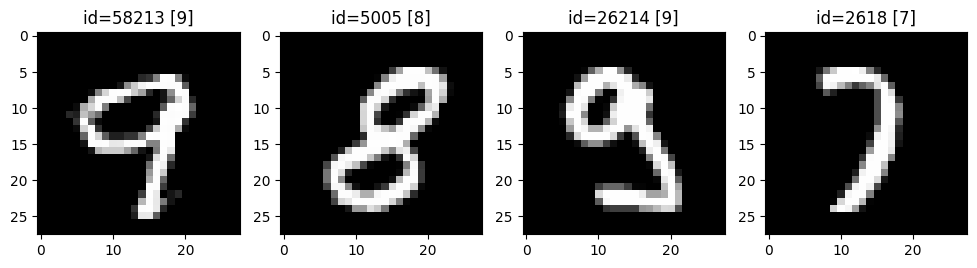

In [22]:
n_examples= 4  # number of examples to plot

# choosing indecies of images (from train) to plot
random.seed(46)
train_examples_ids = random.sample(range(len(mnist_train_ds)), n_examples)

fig, axs = plt.subplots(1, n_examples, figsize=(n_examples * 3, 3))
for ind_ex, ind_train in enumerate(train_examples_ids):
    image, target = mnist_train_ds[ind_train]

    axs[ind_ex].set_title(f'id={ind_train} [{target}]')
    axs[ind_ex].imshow(image, cmap='gray')

plt.show()

In [23]:
image,_ = mnist_train_ds[1]
print(np.array(image).shape)

(28, 28)


## Determing the Computation domain

In [29]:
lx = 8e-3
ly = 8e-3

wavelength = 1064e-9
# number of nodes
Nx = 128
Ny = 128

# creating SimulationParameters exemplar
sim_params = SimulationParameters({
    'W': torch.linspace(-lx / 2, lx / 2, Nx),
    'H': torch.linspace(-ly / 2, ly / 2, Ny),
    'wavelength': wavelength,
})

In [18]:
from torch.utils.data import Dataset
import torchvision.transforms.functional as functional


In [19]:
resize_y = 25
resize_x = 25 # shape for transforms.Resize
# Comment: Looks like in [2] article MNIST pictures were resized to 100 x 100 neurons
x_size_max = Nx
y_size_max = Ny
# paddings along OY
pad_top = int((x_size_max - resize_y) / 2)
pad_bottom = y_size_max - pad_top - resize_y
# paddings along OX
pad_left = int((x_size_max - resize_x) / 2)
pad_right = x_size_max - pad_left - resize_x  # params for transforms.Pad


In [50]:
MODULATION_TYPE = 'amplitude'


image_transform_for_ds = transforms.Compose(
  [
      transforms.ToTensor(),
      transforms.Resize(
          size=(resize_y, resize_x),
          interpolation=InterpolationMode.NEAREST,
      ),
      transforms.Pad(
          padding=(
              pad_left,  # left padding
              pad_top,  # top padding
              pad_right,  # right padding
              pad_bottom  # bottom padding
          ),
          fill=0,
      ),  # padding to match sizes!
      ToWavefront(modulation_type=MODULATION_TYPE),
      GaussModulation(sim_params=sim_params, fwhm_x=1e-3, fwhm_y = 1e-3)# <- select modulation type!!!
      
  ]  
)

In [51]:
class DatasetOfWavefronts(Dataset):

    def __init__(
        self,
        init_ds: Dataset,
        transformations: transforms.Compose,
        sim_params: SimulationParameters,
        target: str = 'label',
        detector_mask: torch.Tensor | None = None
    ):
        """
        Parameters
        ----------
        init_ds : torch.utils.data.Dataset
            An initial dataset (of images and labels).
        transformations : transforms.Compose
            A sequence of transforms that will be applied to dataset elements (images).
        sim_params : SimulationParameters
            Simulation parameters for a further optical network.
        terget : str
            A type of target
                (1) 'label' - returns just a number of class
                (2) 'detector' - returns an expected detector picture
        detector_mask: torch.Tensor | None
            A detector mask to generate target images (if tardet == 'detector')
        """
        self.init_ds = init_ds
        self.transformations = transformations

        self.sim_params = sim_params  # to check if all transforms results in right shape
        self.check_transformations()  # print warnings if necessary

        self.target = target
        self.detector_mask = detector_mask

    def check_transformations(self):
        """
        Checks if transformations transforms an image to a right-shaped Wavefront.
        """
        random_image = functional.to_pil_image(torch.rand(size=(5, 5)))  # random image
        wavefront = self.transformations(random_image)

        # check type
        if not isinstance(wavefront, Wavefront):
            warnings.warn(
                message='An output object is not of the Wavefront type!'
            )

        # compare nodes number of the resulted Wavefront (last two dimensions) with simulation parameters
        sim_nodes_shape = self.sim_params.axes_size(axs=('H', 'W'))

        if not wavefront.size()[-2:] == sim_nodes_shape:
            warnings.warn(
                message='A shape of a resulted Wavefront does not match with SimulationParameters!'
            )

    def __len__(self):
        return len(self.init_ds)

    def __getitem__(self, ind: int) -> tuple:
        """
        Parameters
        ----------
        ind : int
            Index of element to return.

        Returns
        -------
        tuple
            An element of dataset: tuple(Wavefront, class)
            A size of a wavefront must be in a correspondence with simulation parameters!
        """
        raw_image, label = self.init_ds[ind]
        # apply transformations
        wavefront_image = self.transformations(raw_image)

        if self.target == 'label':
            return wavefront_image, label

        if self.target == 'detector':
            if self.detector_mask is None:  # no detector mask provided
                warnings.warn(
                    message='No Detector mask provided to generate targets!'
                )
            else:
                detector_image = torch.where(label == self.detector_mask, 1.0, 0.0)
                return wavefront_image, detector_image

In [52]:
mnist_wf_train_ds = DatasetOfWavefronts(
    init_ds=mnist_train_ds,  # dataset of images
    transformations=image_transform_for_ds,  # image transformation
    sim_params=sim_params,  # simulation parameters
    target='label'
)


In [53]:
print(f'Train data: {len(mnist_train_ds)}')

Train data: 60000


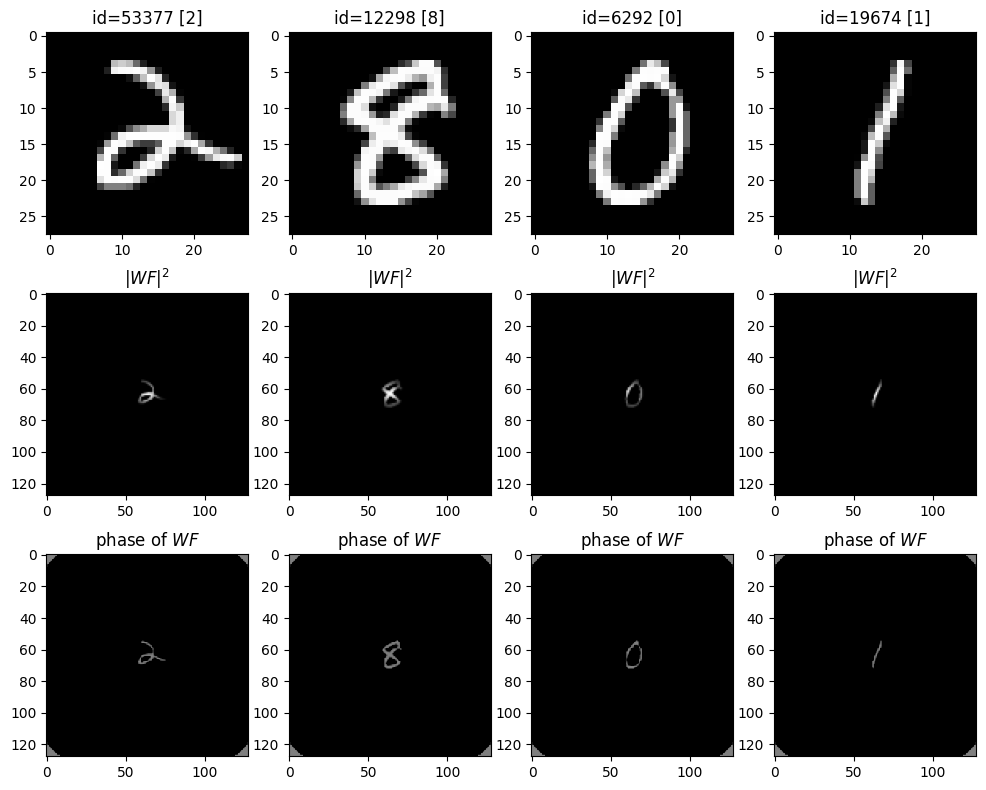

In [55]:
# plot several EXAMPLES from TRAIN dataset
n_examples= 4  # number of examples to plot
# choosing indecies of images (from train) to plot
random.seed(78)
train_examples_ids = random.sample(range(len(mnist_train_ds)), n_examples)

all_examples_wavefronts = []

n_lines = 3
fig, axs = plt.subplots(n_lines, n_examples, figsize=(n_examples * 3, n_lines * 3.2))
for ind_ex, ind_train in enumerate(train_examples_ids):
    image, label = mnist_train_ds[ind_train]
    
    axs[0][ind_ex].set_title(f'id={ind_train} [{label}]')
    axs[0][ind_ex].imshow(image, cmap='gray')

    wavefront, wf_label = mnist_wf_train_ds[ind_train]
    assert isinstance(wavefront, Wavefront)

    all_examples_wavefronts.append(wavefront)

    axs[1][ind_ex].set_title(f'$|WF|^2$')
    # here we can plot intensity for a wavefront
    axs[1][ind_ex].imshow(
        wavefront.intensity, cmap='gray',
        vmin=0, vmax=1
    )
    
    axs[2][ind_ex].set_title(f'phase of $WF$')
    axs[2][ind_ex].imshow(
        wavefront.phase, cmap='gray',
        vmin=0, vmax= 2 * torch.pi
    )

plt.show()

<class 'torch.Tensor'>


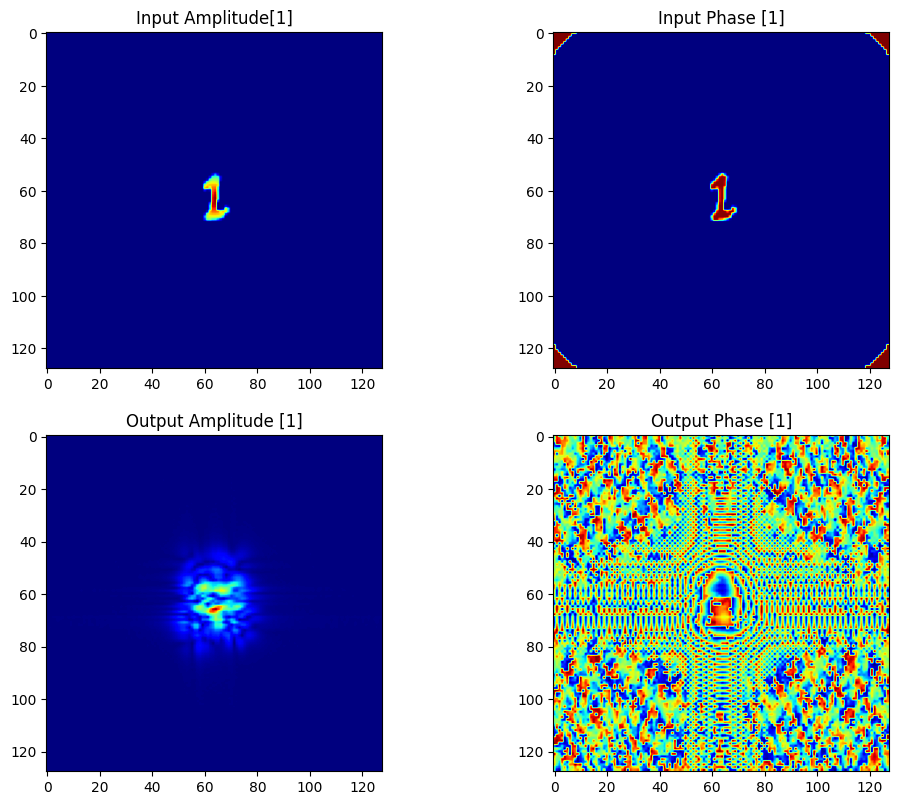

In [73]:
fig, axs = plt.subplots(2, 2, figsize=(n_examples * 3, n_lines * 3.2))
idx = 70
image, label = mnist_wf_train_ds[idx]

slm_height = 1e-3
slm_width =  1e-3
mpixel_number = 3
# Example usage



mask = torch.rand((mpixel_number,mpixel_number), requires_grad = False) * (2 * torch.pi)
slm = elements.SpatialLightModulator(
    simulation_parameters=sim_params,
    mask=mask,
    height=slm_height,
    width=slm_width
)
# slm_transmission_function = slm.transmission_function
# plt.imshow(torch.angle(slm_transmission_function))
# slm_aperture = slm.get_aperture


free_space = elements.FreeSpace(
    simulation_parameters=sim_params,
    distance=100e-3,
    method="AS"
)

lens = elements.ThinLens(
    simulation_parameters=sim_params,
    focal_length= 100e-3,
    radius=8e-3
)
# 
test1 = lens.get_transmission_function()
plt.imshow(torch.angle(test1))
aperture = elements.RoundAperture(
    simulation_parameters=sim_params,  
    radius = 2e-3
)
# )
# 
# 
# # 
wavefront, wf_label = mnist_wf_train_ds[idx]


setup = LinearOpticalSetup([slm, free_space])
gauss_beam = Wavefront.gaussian_beam(
    simulation_parameters=sim_params,
    waist_radius=0.5e-3,
    distance=0
)

input_beam = wavefront
output_wavefront = setup.forward(input_wavefront=input_beam)
output_beam = torch.Tensor(output_wavefront.detach().clone())
# 
print(type(torch.Tensor(output_wavefront.detach().clone())))
axs[0][0].set_title(f'Input Amplitude[{label}]')
axs[0][0].imshow(input_beam.abs(), cmap='jet')
axs[0][1].set_title(f'Input Phase [{label}]')
axs[0][1].imshow(input_beam.phase, cmap='jet')
axs[1][0].set_title(f'Output Amplitude [{label}]')
axs[1][0].imshow(torch.abs(output_beam), cmap='jet')
axs[1][1].set_title(f'Output Phase [{label}]')
axs[1][1].imshow(torch.angle(output_beam), cmap='jet')


In [65]:
import os
from tqdm import tqdm
def save_dataset_batches(dataset, batch_size=1000, output_dir='D:/dataset_neurop/mnist_128_128_lens_100mm/'):
    os.makedirs(output_dir, exist_ok=True)
    n = len(dataset)
    for start in tqdm(range(0, n, batch_size)):
        end = min(start + batch_size, n)
        inputs = []
        outputs = []
        for i in range(start, end):
            x,_ = dataset[i]
            y = setup.forward(input_wavefront=x)
            inputs.append(torch.Tensor(x))
            outputs.append(torch.Tensor(y))
        inputs_tensor = torch.stack(inputs)
        outputs_tensor = torch.stack(outputs)
        torch.save({inputs_tensor, outputs_tensor}, f'{output_dir}/batch_{start}_{end-1}.pt')


In [439]:
save_dataset_batches(mnist_wf_train_ds)

100%|██████████| 60/60 [02:44<00:00,  2.75s/it]


In [13]:
data = torch.load("D:/dataset_neurop/mnist_128_128_lens_100mm/batch_0_999.pt", weights_only="False")

In [18]:
in1, out1 = data

torch.Size([1000, 128, 128])


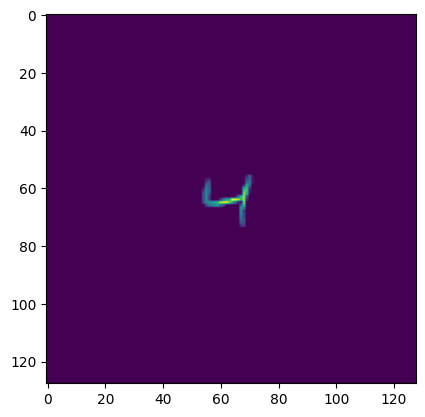

In [21]:
print(in1.shape)
plt.imshow(torch.abs(in1[2,:,:]))
plt.imshow(torch.abs(out1[2, :, :]))
